# Demand-side flexibility: pre-cooling the buildings

The previous notebook got its flexibility from a tank. This one gets it from the
buildings themselves, and needs no storage at all.

The idea is simple: a building has thermal mass, and occupants tolerate a band of
temperatures rather than a single setpoint. Cool the zone to the bottom of that
band while electricity is cheap, and it will coast back up through the expensive
afternoon without the chiller doing much. The building *is* the store.

The reason the pre-upgrade tool could not represent this: a `Building` was a
`SimpleHeatExchanger` with a scalar `Q`. There is no indoor temperature to
pre-cool, no capacitance to store anything in, and no comfort band to trade
against. Making the load a *consequence* of an indoor temperature state is what
unlocks the analysis.

$$
C\,\frac{\mathrm{d}T}{\mathrm{d}t} \;=\; UA\,(T_\text{air}-T) \;+\; \dot Q_\text{solar} \;+\; \dot Q_\text{internal} \;-\; \dot Q_\text{cool}
$$

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from discoolpy import (
    Building, ThermalMass, EnvelopeThermal,
    assess_flexibility, flexibility_envelope, load_yaml_config,
    make_weather_and_load_profiles, run_configured_case,
)
from discoolpy.config_schema import make_buildings

CONFIG = Path("../configs/config_precooling_flexibility.yaml")
config = load_yaml_config(CONFIG)
for b in config["buildings"]:
    tm = b["thermal_mass"]
    tau_h = tm["capacitance_MJ_K"] * 1e6 / (b["envelope"]["UA_W_K"] * 3600)
    print(f"{b['label']:<15} UA={b['envelope']['UA_W_K']:>6.0f} W/K   "
          f"C={tm['capacitance_MJ_K']:>5.0f} MJ/K   tau={tau_h:>5.1f} h   "
          f"band {tm['min_temperature_degC']}-{tm['max_temperature_degC']} °C")

office tower    UA=  6200 W/K   C=  420 MJ/K   tau= 18.8 h   band 20.5-26.0 °C
hotel           UA=  4800 W/K   C=  300 MJ/K   tau= 17.4 h   band 21.0-25.0 °C
retail podium   UA=  4100 W/K   C=  150 MJ/K   tau= 10.2 h   band 21.5-26.5 °C


## 1. What one zone does, on its own

Before touching the network, look at a single zone. Three control strategies over
a hot day, integrated **exactly** over each step (the analytic solution of the RC
equation, not forward Euler, with a comfort band only a few kelvin wide and a
time constant of many hours, an explicit step large enough to be useful would
overshoot the band and report flexibility that does not exist).

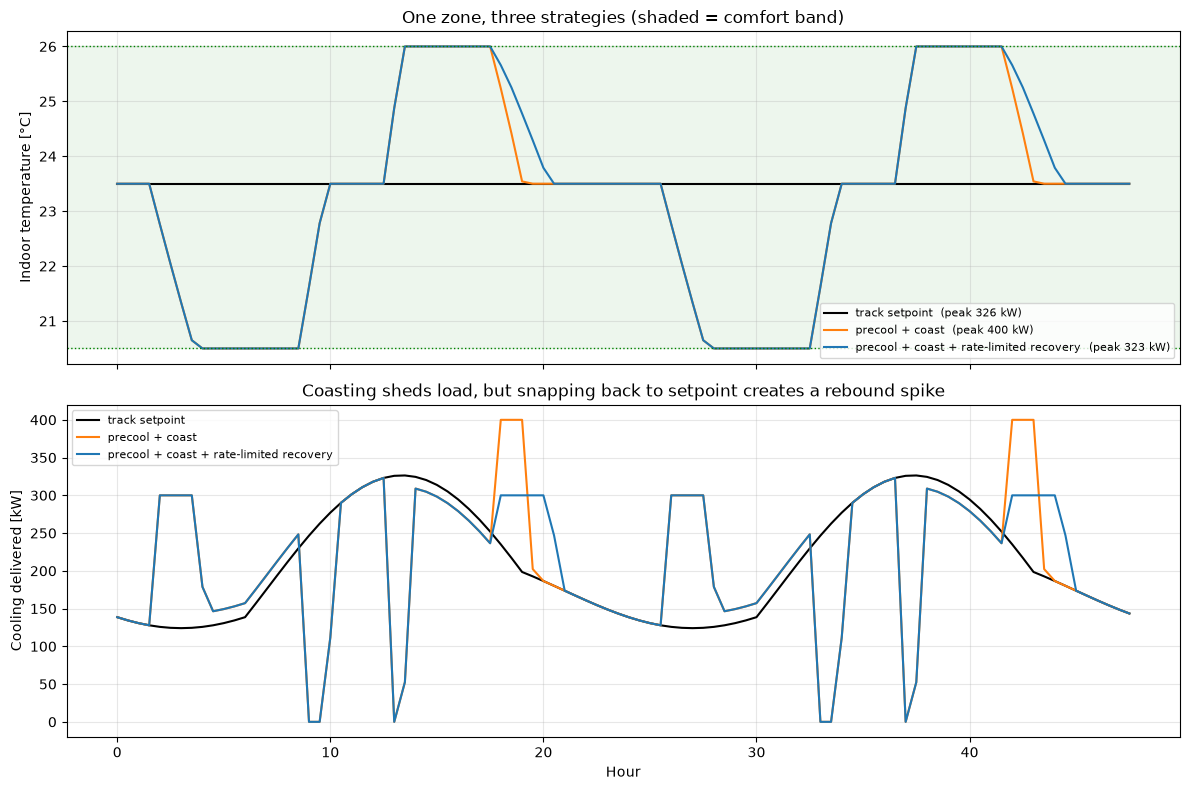

In [2]:
UA, C = 6200.0, 420e6
hours = np.arange(0, 48, 0.5)
T_air = 37.0 + 8.0 * np.sin(2 * np.pi * (hours - 9) / 24)
gains = 90_000 + 110_000 * np.clip(np.sin(np.pi * (hours % 24 - 6) / 13), 0, 1)

def simulate(modes):
    mass = ThermalMass(capacitance_J_K=C, setpoint_degC=23.5,
                       min_temperature_degC=20.5, max_temperature_degC=26.0,
                       max_cooling_W=400_000, precool_max_cooling_W=300_000)
    T, Q = [], []
    for i, h in enumerate(hours):
        state = mass.step(0.5, UA, T_air[i], gains[i], mode=modes(h % 24))
        T.append(state.indoor_temperature_after_degC)
        Q.append(state.cooling_delivered_W)
    return np.array(T), np.array(Q)

strategies = {
    "track setpoint":     lambda h: "track",
    "precool + coast":    lambda h: "precool" if 2 <= h < 9 else ("coast" if 13 <= h < 18 else "track"),
    "precool + coast + rate-limited recovery":
                          lambda h: "precool" if 2 <= h < 9 else ("coast" if 13 <= h < 18
                                    else ("recover" if 18 <= h < 22 else "track")),
}

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for (name, modes), colour in zip(strategies.items(), ["black", "tab:orange", "tab:blue"]):
    T, Q = simulate(modes)
    ax[0].plot(hours, T, color=colour, label=f"{name}  (peak {Q.max()/1e3:.0f} kW)")
    ax[1].plot(hours, Q / 1e3, color=colour, label=name)
ax[0].axhspan(20.5, 26.0, color="green", alpha=0.07)
ax[0].axhline(20.5, color="green", ls=":", lw=1); ax[0].axhline(26.0, color="green", ls=":", lw=1)
ax[0].set_ylabel("Indoor temperature [°C]"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[0].set_title("One zone, three strategies (shaded = comfort band)")
ax[1].set_ylabel("Cooling delivered [kW]"); ax[1].set_xlabel("Hour")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[1].set_title("Coasting sheds load, but snapping back to setpoint creates a rebound spike")
plt.tight_layout(); plt.show()

Notice the middle (orange) trace in the lower panel. Coasting sheds load through
the afternoon exactly as intended, and then at 18:00 the controller asks for the
setpoint again in a single step and the coil goes to full output. That **rebound
peak** is larger than anything in the baseline. Do this across a whole district
simultaneously and the demand-response event has made the peak worse.

The blue trace recovers at the pre-cooling rate limit instead, which spreads the
recovery over four hours and keeps the peak down. This is not a modelling
artefact to be smoothed away. It is the single most common way a real
pre-cooling scheme fails, and a model that cannot show it is not useful for
designing one.

In [3]:
# How much flexibility is available, and for how long? Power alone does not say.
mass = ThermalMass(capacitance_J_K=C, setpoint_degC=23.5, min_temperature_degC=20.5,
                   max_temperature_degC=26.0, max_cooling_W=400_000)
flex = mass.flexibility_W(dt_h=1.0, UA_W_K=UA, ambient_degC=40.0, gain_W=150_000)
for k, v in flex.items():
    unit = "kW" if k.endswith("_W") else "kWh"
    print(f"  {k:<22} {v/1000 if k.endswith('_W') else v:8.1f} {unit}")
print("\n  precool_energy_kWh is the deliverable resource: how much cooling the zone")
print("  can absorb before it hits the band floor. It falls to zero at the floor")
print("  even while the power figure stays large.")

  baseline_W                252.3 kW
  increase_W                147.7 kW
  decrease_W                252.3 kW
  precool_energy_kWh        350.0 kWh
  coast_energy_kWh          291.7 kWh

  precool_energy_kWh is the deliverable resource: how much cooling the zone
  can absorb before it hits the band floor. It falls to zero at the floor
  even while the power figure stays large.


## 2. The whole network

Now run the three-building network twice over two days of Riyadh weather: once
holding setpoints, once pre-cooling (staggered by an hour per building) and
coasting through the 13:00-18:00 tariff peak, with rate-limited recovery.

The distribution pipes gain heat from the soil throughout, in both cases.

In [4]:
INTERNAL_GAIN_FRACTION = 0.22   # profile carries internal gains only under thermal_mass
PRECOOL, COAST, RECOVERY_H = (2, 9), (13, 18), 4

base = make_weather_and_load_profiles(config)
labels = [b["label"] for b in config["buildings"]]
for label in labels:
    base[f"{label}_Q_W"] *= INTERNAL_GAIN_FRACTION

tracking = base.copy()
flexible = base.copy()
hour = pd.to_datetime(base["timestamp"]).dt.hour
for offset, label in enumerate(labels):
    tracking[f"{label}_mass_mode"] = "track"
    mode = pd.Series("track", index=base.index)
    mode[(hour >= PRECOOL[0] + offset) & (hour < PRECOOL[1])] = "precool"
    mode[(hour >= COAST[0]) & (hour < COAST[1])] = "coast"
    mode[(hour >= COAST[1]) & (hour < COAST[1] + RECOVERY_H)] = "recover"
    flexible[f"{label}_mass_mode"] = mode.to_numpy()

print(f"{len(base)} snapshots; staggered pre-cool starts at "
      f"{[PRECOOL[0] + i for i in range(len(labels))]}h")

96 snapshots; staggered pre-cool starts at [2, 3, 4]h


In [5]:
ref  = run_configured_case(config, tracking, "nb_tracking",  use_storage=False, progress=False)
flex = run_configured_case(config, flexible, "nb_precooling", use_storage=False, progress=False)
print(f"max chilled-water energy residual: "
      f"{max(ref.chw_energy_residual_W.abs().max(), flex.chw_energy_residual_W.abs().max()):.2e} W")

Operating point below characteristic line range: X=0.435 with minimum of 0.55782 at component precooling_chiller_compressor.


Operating point below characteristic line range: X=0.41 with minimum of 0.55782 at component precooling_chiller_compressor.


Operating point below characteristic line range: X=0.386 with minimum of 0.55782 at component precooling_chiller_compressor.


Operating point below characteristic line range: X=0.364 with minimum of 0.55782 at component precooling_chiller_compressor.


Operating point below characteristic line range: X=0.344 with minimum of 0.55782 at component precooling_chiller_compressor.


...

Operating point below characteristic line range: X=0.488 with minimum of 0.55782 at component precooling_chiller_compressor.


Operating point below characteristic line range: X=0.029 with minimum of 0.55782 at component precooling_chiller_compressor.


Operating point below characteristic line range: X=0.22 with minimum of 0.55782 at component precooling_chiller_compressor.


Operating point below characteristic line range: X=0.085 with minimum of 0.55782 at component precooling_chiller_compressor.


max chilled-water energy residual: 9.96e-08 W


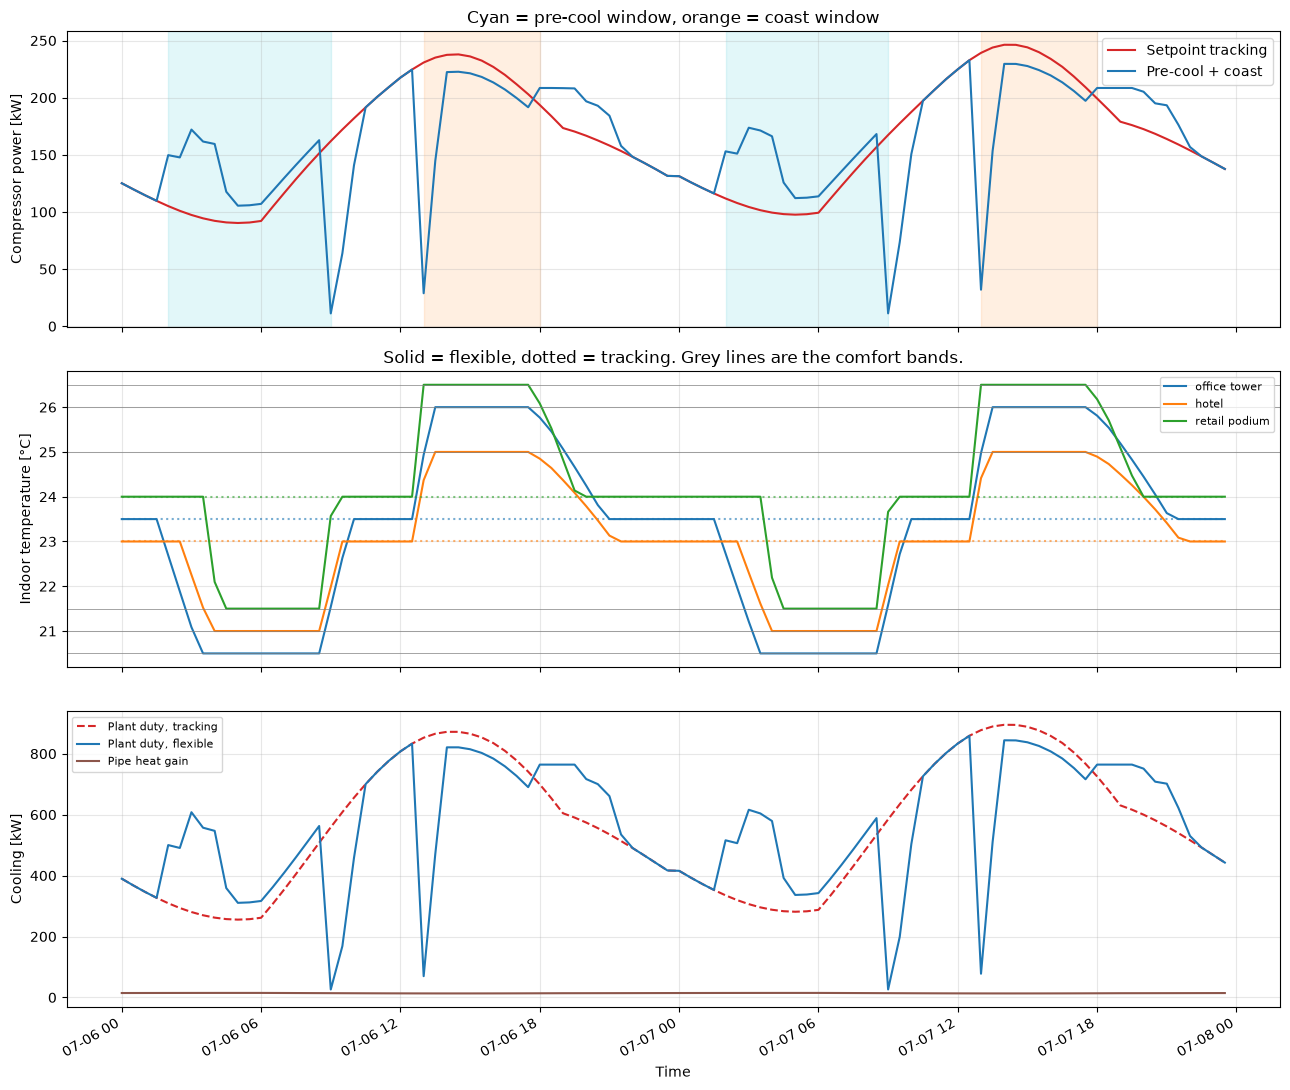

In [6]:
r = ref.copy();  r["timestamp"]  = pd.to_datetime(r["timestamp"])
f = flex.copy(); f["timestamp"] = pd.to_datetime(f["timestamp"])

fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
ax[0].plot(r.timestamp, r.compressor_power_W / 1e3, color="tab:red", label="Setpoint tracking")
ax[0].plot(f.timestamp, f.compressor_power_W / 1e3, color="tab:blue", label="Pre-cool + coast")
for lo, hi, c, lbl in [(PRECOOL[0], PRECOOL[1], "tab:cyan", "pre-cool"),
                       (COAST[0], COAST[1], "tab:orange", "coast")]:
    for day in pd.date_range(r.timestamp.min().normalize(), r.timestamp.max(), freq="1D"):
        ax[0].axvspan(day + pd.Timedelta(hours=lo), day + pd.Timedelta(hours=hi),
                      color=c, alpha=0.12)
ax[0].set_ylabel("Compressor power [kW]"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("Cyan = pre-cool window, orange = coast window")

for label, colour in zip(labels, ["tab:blue", "tab:orange", "tab:green"]):
    safe = label.replace(" ", "_")
    ax[1].plot(f.timestamp, f[f"{safe}_T_indoor_degC"], color=colour, label=f"{label}")
    ax[1].plot(r.timestamp, r[f"{safe}_T_indoor_degC"], color=colour, ls=":", alpha=0.6)
for item in config["buildings"]:
    tm = item["thermal_mass"]
    ax[1].axhline(tm["min_temperature_degC"], color="grey", lw=0.5)
    ax[1].axhline(tm["max_temperature_degC"], color="grey", lw=0.5)
ax[1].set_ylabel("Indoor temperature [°C]"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[1].set_title("Solid = flexible, dotted = tracking. Grey lines are the comfort bands.")

ax[2].plot(r.timestamp, r.chiller_Q_evap_W / 1e3, color="tab:red", ls="--", label="Plant duty, tracking")
ax[2].plot(f.timestamp, f.chiller_Q_evap_W / 1e3, color="tab:blue", label="Plant duty, flexible")
ax[2].plot(r.timestamp, r.pipe_heat_gain_W / 1e3, color="tab:brown", label="Pipe heat gain")
ax[2].set_ylabel("Cooling [kW]"); ax[2].set_xlabel("Time"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

In [7]:
# Comfort is a hard constraint, so check it explicitly rather than trusting it.
for item in config["buildings"]:
    safe = item["label"].replace(" ", "_")
    tm = item["thermal_mass"]
    lo, hi = f[f"{safe}_T_indoor_degC"].min(), f[f"{safe}_T_indoor_degC"].max()
    breach = f[f"{safe}_band_violation_K"].max()
    ok = "OK" if breach <= 1e-6 else f"BREACHED by {breach:.2f} K"
    print(f"{item['label']:<15} {lo:5.2f} to {hi:5.2f} °C "
          f"(band {tm['min_temperature_degC']}-{tm['max_temperature_degC']})   {ok}")

office tower    20.50 to 26.00 °C (band 20.5-26.0)   OK
hotel           21.00 to 25.00 °C (band 21.0-25.0)   OK
retail podium   21.50 to 26.50 °C (band 21.5-26.5)   OK


In [8]:
economics = config.get("economics", {})
report = assess_flexibility(
    ref, flex,
    reference_name="setpoint tracking", flexible_name="pre-cool and coast",
    tariff=economics.get("tariff"),
    carbon_intensity=economics.get("carbon_intensity_kg_kWh"),
    peak_hours=range(*COAST),
)
from IPython.display import Markdown, display
display(Markdown(report.to_markdown()))

# Flexibility assessment: `pre-cool and coast` vs `setpoint tracking`

Horizon resolution: 0.5 h.

## Headline

| Metric | Reference | Flexible | Change |
|---|---:|---:|---:|
| Peak compressor power [kW] | 246.3 | 232.8 | -13.5 (-5.5%) |
| Compressor energy [kWh] | 7876.4 | 7799.6 | -76.8 (-1.0%) |
| Load factor [-] | 0.666 | 0.698 | +0.032 |
| Mean COP [-] | 3.351 | 3.371 | +0.020 |
| Max ramp up [kW/h] | 24.9 | 243.0 | +218.1 |

## Where the flexibility went

| Quantity | Value |
|---|---:|
| Cooling charged into store [kWh] | 0.0 |
| Cooling discharged from store [kWh] | 0.0 |
| Store losses (ambient gain + standby) [kWh] | 0.0 |
| Net change in stored cooling over the horizon [kWh] | +0.0 |
| Thermal round-trip efficiency [-] | n/a |
| **Electric** round-trip efficiency [-] | n/a |
| COP while charging, vs the same hour in the reference [-] | n/a |
| Energy shifted out of the peak [kWh] | 408.6 |

## Economics

| Quantity | Reference | Flexible | Saving |
|---|---:|---:|---:|
| Electricity cost | 1201.29 | 1107.69 | +93.59 (+7.8%) |
| Emissions [kg CO2e] | 4332.0 | 4289.8 | +42.3 |

## Parasitic heat gains (reference)

| Source | Energy [kWh] | Share of building demand |
|---|---:|---:|
| Building demand served | 25896.0 | 100.0% |
| Distribution pipe gain | 675.0 | 2.61% |
| Storage ambient gain | 0.0 | 0.00% |
| Pump heat | 514.7 | 1.99% |
| **Plant cooling produced** | **27085.7** | 104.59% |

## Parasitic heat gains (flexible)

| Source | Energy [kWh] | Share of building demand |
|---|---:|---:|
| Building demand served | 25900.1 | 100.0% |
| Distribution pipe gain | 675.1 | 2.61% |
| Storage ambient gain | 0.0 | 0.00% |
| Pump heat | 514.7 | 1.99% |
| **Plant cooling produced** | **27089.9** | 104.59% |

## 3. Why this is not free

Pre-cooling is often described as "free storage". It is not, for three reasons
this model makes visible:

1. **You cool a warmer building.** Pre-cooling happens when the zone is above the
   band floor, so every kelvin of pre-cooling is delivered against a larger
   envelope temperature difference than the cooling it displaces. Some of the
   energy leaks straight back out.
2. **You still pay the distribution gain.** The pipes gain heat whether the
   buildings are pre-cooling or coasting, and the plant carries it either way.
3. **The recovery has to be managed.** Without a rate limit the rebound peak can
   exceed the peak you avoided, as the first plot showed.

The pay-off is that the resource costs no capital: it is already installed in
every building on the network.

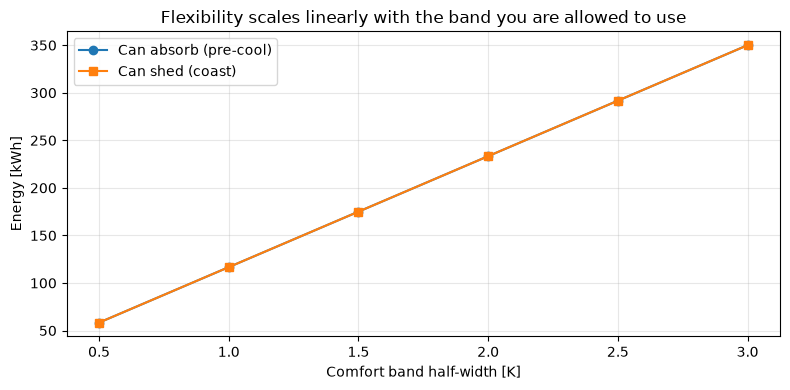

 half-band [K]  shiftable [kWh]  sheddable [kWh]
           0.5        58.333333        58.333333
           1.0       116.666667       116.666667
           1.5       175.000000       175.000000
           2.0       233.333333       233.333333
           2.5       291.666667       291.666667
           3.0       350.000000       350.000000


In [9]:
# Sensitivity: how much does the width of the comfort band matter?
rows = []
for half_band in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    m = ThermalMass(capacitance_J_K=C, setpoint_degC=23.5,
                    min_temperature_degC=23.5 - half_band,
                    max_temperature_degC=23.5 + half_band,
                    max_cooling_W=400_000)
    fx = m.flexibility_W(1.0, UA, 40.0, 150_000)
    rows.append({"half-band [K]": half_band,
                 "shiftable [kWh]": fx["precool_energy_kWh"],
                 "sheddable [kWh]": fx["coast_energy_kWh"]})
sens = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sens["half-band [K]"], sens["shiftable [kWh]"], "o-", label="Can absorb (pre-cool)")
ax.plot(sens["half-band [K]"], sens["sheddable [kWh]"], "s-", label="Can shed (coast)")
ax.set_xlabel("Comfort band half-width [K]"); ax.set_ylabel("Energy [kWh]")
ax.set_title("Flexibility scales linearly with the band you are allowed to use")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(sens.to_string(index=False))

## What to take away

* **Flexibility scales with the comfort band and the thermal mass**, linearly in
  both. Negotiating one extra kelvin of tolerance is worth as much as a
  substantial tank.
* **Rate limits matter more than the strategy.** The same pre-cool/coast plan
  either reduces or increases the peak depending purely on how the recovery is
  managed.
* **Comfort must be a hard constraint, and it must be checked.** DisCoolPy
  reports `*_band_violation_K` per building and warns when the terminal units
  ran out of capacity, because load shed by overheating a building is not
  flexibility.